# LSTM with Pre-trained Word2Vec Embeddings

This notebook compares LSTM fake news detection using:

1. **Frozen Word2Vec embeddings**: Pre-trained embeddings fixed during training
2. **Fine-tuned Word2Vec embeddings**: Pre-trained embeddings updated during training

**Based on**: lstm_experiment.ipynb (92.1% accuracy with learned embeddings)

**Key difference**: Uses pre-trained Word2Vec model from `data/processed/word2vec.model` (100-dim) instead of randomly initialized embeddings (128-dim).


In [1]:
import sys
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Gensim for Word2Vec
from gensim.models import Word2Vec

# Sklearn for metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Add project root to path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import modules
from src.data import process_dataset, make_split
from src.models import train_model as train_model_module

load_config = train_model_module.load_config

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
print("✓ Imports successful")


Using device: mps
✓ Imports successful


In [2]:
# Load configuration and define paths
config = load_config(str(project_root / "config" / "config.yaml"))

# Get column configuration
FEATURE_COLUMN = config["columns"]["feature_column"]
LABEL_COLUMN = config["columns"]["label_column"]
ID_COLUMN = config["columns"]["id_column"]

print("Configuration loaded:")
print(f"  Feature column (X): '{FEATURE_COLUMN}'")
print(f"  Label column (y):   '{LABEL_COLUMN}'")
print(f"  ID column:          '{ID_COLUMN}'")


Configuration loaded:
  Feature column (X): 'text'
  Label column (y):   'label'
  ID column:          'id'


## 1. Data Processing

Load raw data, clean source attribution, and remove duplicates.


In [3]:
# Define paths
raw_data_path = project_root / "data" / "raw" / "WELFake_Dataset.csv"
cleaned_data_path = project_root / "data" / "processed" / "cleaned_dataset.csv"

# Process dataset: load, clean source attribution, deduplicate
df = process_dataset(
    input_path=str(raw_data_path),
    output_path=str(cleaned_data_path),
    feature_column=FEATURE_COLUMN,
    label_column=LABEL_COLUMN,
    id_column=ID_COLUMN
)


DATA PROCESSING
Input:  /Users/alanye/Fake-News-Group-3/data/raw/WELFake_Dataset.csv
Output: /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

1. Loading dataset...
   Loaded 72,134 rows
   Columns: ['id', 'title', 'text', 'label']

2. Cleaning source attribution from 'text' column...
   Removing patterns like '(Reuters) -', '(AP) -', etc.
   ✓ Source attribution removed

3. Removing duplicate articles (based on 'text')...
   Removed 27,695 duplicates
   Remaining: 44,439 unique articles

4. Label distribution ('label' column):
   0 (Real): 29,561 (66.5%)
   1 (Fake): 14,878 (33.5%)

5. Saving cleaned data...
✓ Saved 44439 rows to /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

✓ DATA PROCESSING COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Total rows:     44,439
  Saved to:       /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv


## 2. Train/Test Split

Create stratified train/test split (80/20) based on label column.


In [4]:
processed_dir = project_root / "data" / "processed"

train_df, test_df = make_split(
    input_path=str(cleaned_data_path),
    output_dir=str(processed_dir),
    test_size=config["models"]["test_size"],
    random_seed=config["models"]["random_seed"],
    label_column=LABEL_COLUMN,
    feature_column=FEATURE_COLUMN
)

print(f"\nTrain set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")


TRAIN/TEST SPLIT

1. Loading data from /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv...
   Loaded 44,439 rows

2. Validating columns...
   Feature column (X): 'text'
   Label column (y):   'label'
   ✓ All required columns present

3. Label distribution (before split):
   0 (Real): 29,561 (66.5%)
   1 (Fake): 14,878 (33.5%)

4. Splitting data (test_size=0.2, random_seed=42)...

5. Saving splits...
   Train: /Users/alanye/Fake-News-Group-3/data/processed/train.csv (35,551 rows)
   Test:  /Users/alanye/Fake-News-Group-3/data/processed/test.csv (8,888 rows)

✓ SPLIT COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Train samples:  35,551
  Test samples:   8,888

Train set: 35551 samples
Test set: 8888 samples


## 3. Load Pre-trained Word2Vec Model

Load the Word2Vec model trained during feature engineering and build the embedding matrix.


In [5]:
# Load pre-trained Word2Vec model
w2v_model_path = project_root / "data" / "processed" / "word2vec.model"
w2v_model = Word2Vec.load(str(w2v_model_path))

print("="*60)
print("PRE-TRAINED WORD2VEC MODEL")
print("="*60)
print(f"\nModel loaded from: {w2v_model_path}")
print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"Embedding dimension: {w2v_model.wv.vector_size}")
print(f"\nSample words in vocabulary:")
sample_words = list(w2v_model.wv.key_to_index.keys())[:10]
for word in sample_words:
    print(f"  - {word}")


PRE-TRAINED WORD2VEC MODEL

Model loaded from: /Users/alanye/Fake-News-Group-3/data/processed/word2vec.model
Vocabulary size: 521242
Embedding dimension: 100

Sample words in vocabulary:
  - the
  - to
  - of
  - and
  - a
  - in
  - that
  - on
  - for
  - is


In [6]:
# LSTM Hyperparameters
# Note: EMBEDDING_DIM is 100 to match Word2Vec (vs 128 in original LSTM)
EMBEDDING_DIM = w2v_model.wv.vector_size  # 100 from Word2Vec
MAX_SEQ_LEN = 256
HIDDEN_DIM = 64
DROPOUT = 0.3
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.001

print("LSTM Hyperparameters:")
print(f"  Word2Vec vocab size: {len(w2v_model.wv)}")
print(f"  Max sequence length: {MAX_SEQ_LEN}")
print(f"  Embedding dimension: {EMBEDDING_DIM} (from Word2Vec)")
print(f"  Hidden dimension: {HIDDEN_DIM}")
print(f"  Dropout: {DROPOUT}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")


LSTM Hyperparameters:
  Word2Vec vocab size: 521242
  Max sequence length: 256
  Embedding dimension: 100 (from Word2Vec)
  Hidden dimension: 64
  Dropout: 0.3
  Batch size: 64
  Epochs: 100
  Learning rate: 0.001


## 4. Build Vocabulary and Embedding Matrix from Word2Vec


In [7]:
def simple_tokenize(text):
    """Simple tokenizer: lowercase, keep alphanumeric, split on whitespace."""
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()


class Word2VecVocabulary:
    """Vocabulary built from pre-trained Word2Vec model."""
    
    def __init__(self, w2v_model):
        self.w2v_model = w2v_model
        self.embedding_dim = w2v_model.wv.vector_size
        
        # Build word2idx: PAD=0, UNK=1, then Word2Vec words
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        
        for word in w2v_model.wv.key_to_index.keys():
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
    
    def build_embedding_matrix(self):
        """Create embedding matrix from Word2Vec weights."""
        vocab_size = len(self.word2idx)
        embedding_matrix = np.zeros((vocab_size, self.embedding_dim))
        
        # PAD (idx 0) stays as zeros
        # UNK (idx 1) - use mean of all vectors
        embedding_matrix[1] = np.mean(self.w2v_model.wv.vectors, axis=0)
        
        # Copy Word2Vec vectors for known words
        for word, idx in self.word2idx.items():
            if word in ['<PAD>', '<UNK>']:
                continue
            embedding_matrix[idx] = self.w2v_model.wv[word]
        
        return torch.FloatTensor(embedding_matrix)
    
    def encode(self, text, max_len=256):
        """Convert text to padded sequence of indices."""
        tokens = simple_tokenize(text)
        indices = [self.word2idx.get(t, 1) for t in tokens]  # 1 = UNK
        
        # Truncate or pad
        if len(indices) > max_len:
            indices = indices[:max_len]
        else:
            indices = indices + [0] * (max_len - len(indices))  # 0 = PAD
            
        return indices
    
    def __len__(self):
        return len(self.word2idx)


# Build vocabulary from Word2Vec
print("Building vocabulary from Word2Vec model...")
vocab = Word2VecVocabulary(w2v_model)
embedding_matrix = vocab.build_embedding_matrix()

print(f"  Vocabulary size: {len(vocab)} tokens")
print(f"  Embedding matrix shape: {embedding_matrix.shape}")
print(f"  PAD vector norm: {torch.norm(embedding_matrix[0]):.4f} (should be ~0)")
print(f"  UNK vector norm: {torch.norm(embedding_matrix[1]):.4f} (mean of all vectors)")


Building vocabulary from Word2Vec model...
  Vocabulary size: 521244 tokens
  Embedding matrix shape: torch.Size([521244, 100])
  PAD vector norm: 0.0000 (should be ~0)
  UNK vector norm: 0.2924 (mean of all vectors)


In [8]:
# Check OOV rate in training data
print("Analyzing OOV (Out-of-Vocabulary) rate...")

total_tokens = 0
oov_tokens = 0
oov_examples = []

for text in tqdm(train_df[FEATURE_COLUMN].tolist(), desc="Checking OOV"):
    tokens = simple_tokenize(text)
    for token in tokens:
        total_tokens += 1
        if token not in vocab.word2idx:
            oov_tokens += 1
            if len(oov_examples) < 20:
                oov_examples.append(token)

oov_rate = oov_tokens / total_tokens * 100 if total_tokens > 0 else 0
print(f"\n  Total tokens: {total_tokens:,}")
print(f"  OOV tokens: {oov_tokens:,} ({oov_rate:.2f}%)")
print(f"\n  Sample OOV tokens: {oov_examples[:10]}")


Analyzing OOV (Out-of-Vocabulary) rate...


Checking OOV: 100%|██████████| 35551/35551 [00:09<00:00, 3922.77it/s]


  Total tokens: 20,097,592
  OOV tokens: 979,440 (4.87%)

  Sample OOV tokens: ['afl', 'bernie', 'janet', 'yellen', 'theresa', 'england', 'carney', 'zimbabwe', 'switzerland', 'tuesday']


## 5. Create Datasets and DataLoaders


In [9]:
class TextDataset(Dataset):
    """PyTorch Dataset for text classification."""
    
    def __init__(self, texts, labels, vocab, max_len=256):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        encoded = self.vocab.encode(text, self.max_len)
        
        return {
            'input_ids': torch.tensor(encoded, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.float)
        }


# Create datasets
print("Creating datasets...")
train_dataset = TextDataset(
    train_df[FEATURE_COLUMN].tolist(),
    train_df[LABEL_COLUMN].tolist(),
    vocab,
    max_len=MAX_SEQ_LEN
)

test_dataset = TextDataset(
    test_df[FEATURE_COLUMN].tolist(),
    test_df[LABEL_COLUMN].tolist(),
    vocab,
    max_len=MAX_SEQ_LEN
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"  Train batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")


Creating datasets...
  Train batches: 556
  Test batches: 139


## 6. LSTM Model with Pre-trained Embeddings

Define LSTM classifier that can use frozen or fine-tuned pre-trained embeddings.


In [10]:
class LSTMClassifierW2V(nn.Module):
    """LSTM classifier with pre-trained Word2Vec embeddings."""
    
    def __init__(self, embedding_matrix, hidden_dim, dropout=0.3, freeze_embeddings=True):
        super(LSTMClassifierW2V, self).__init__()
        
        vocab_size, embedding_dim = embedding_matrix.shape
        
        # Load pre-trained embeddings
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=freeze_embeddings,
            padding_idx=0
        )
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)
        
        self.freeze_embeddings = freeze_embeddings
        
    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embedding_dim)
        
        # LSTM output
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Use the last time step output
        last_output = lstm_out[:, -1, :]  # (batch, hidden_dim)
        
        # Apply dropout and FC layer
        dropped = self.dropout(last_output)
        output = self.fc(dropped)  # (batch, 1)
        
        return output.view(-1)  # Flatten to (batch,)


# Show model architecture with frozen embeddings
print("Model architecture (frozen embeddings):")
model_frozen = LSTMClassifierW2V(
    embedding_matrix=embedding_matrix,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

print(model_frozen)
total_params = sum(p.numel() for p in model_frozen.parameters())
trainable_params = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters (frozen): {trainable_params:,}")

# Compare with fine-tuned
model_finetune = LSTMClassifierW2V(
    embedding_matrix=embedding_matrix,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)
trainable_finetune = sum(p.numel() for p in model_finetune.parameters() if p.requires_grad)
print(f"Trainable parameters (fine-tuned): {trainable_finetune:,}")


Model architecture (frozen embeddings):
LSTMClassifierW2V(
  (embedding): Embedding(521244, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 52,166,961
Trainable parameters (frozen): 42,561
Trainable parameters (fine-tuned): 52,166,961


## 7. Training Functions


In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(loader, desc="Training", leave=False):
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predictions = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataset."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), accuracy, all_preds, all_labels


def train_model_full(model, train_loader, test_loader, criterion, optimizer, device,
                     epochs=100, patience=20, model_name="model"):
    """Full training loop with early stopping."""
    print("="*60)
    print(f"TRAINING: {model_name}")
    print("="*60)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_model_state = None
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 40)
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate
        val_loss, val_acc, _, _ = evaluate(model, test_loader, criterion, device)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"  ✓ New best model saved (val_loss: {best_val_loss:.4f})")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement for {epochs_without_improvement}/{patience} epochs")
            
            if epochs_without_improvement >= patience:
                print(f"\n⚠ Early stopping triggered at epoch {epoch + 1}")
                break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Restored best model weights (val_loss: {best_val_loss:.4f})")
    
    print("\n" + "="*60)
    print(f"✓ TRAINING COMPLETE: {model_name}")
    print("="*60)
    
    return model, history


## 8. Train Model A: Frozen Word2Vec Embeddings

Pre-trained embeddings are fixed during training.


In [12]:
# Initialize model with frozen embeddings
model_frozen = LSTMClassifierW2V(
    embedding_matrix=embedding_matrix,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion_frozen = nn.BCEWithLogitsLoss()
optimizer_frozen = optim.Adam(model_frozen.parameters(), lr=LEARNING_RATE)

# Train
model_frozen, history_frozen = train_model_full(
    model_frozen, train_loader, test_loader, 
    criterion_frozen, optimizer_frozen, device,
    epochs=EPOCHS, patience=20,
    model_name="LSTM + Word2Vec (Frozen)"
)


TRAINING: LSTM + Word2Vec (Frozen)

Epoch 1/100
----------------------------------------


  Train Loss: 0.4968 | Train Acc: 0.7529
  Val Loss:   0.5347 | Val Acc:   0.6837
  ✓ New best model saved (val_loss: 0.5347)

Epoch 2/100
----------------------------------------


  Train Loss: 0.4748 | Train Acc: 0.7728
  Val Loss:   0.3955 | Val Acc:   0.8435
  ✓ New best model saved (val_loss: 0.3955)

Epoch 3/100
----------------------------------------


  Train Loss: 0.5257 | Train Acc: 0.7329
  Val Loss:   0.4796 | Val Acc:   0.7698
  No improvement for 1/20 epochs

Epoch 4/100
----------------------------------------


  Train Loss: 0.4359 | Train Acc: 0.7984
  Val Loss:   0.6012 | Val Acc:   0.6652
  No improvement for 2/20 epochs

Epoch 5/100
----------------------------------------


...

  Train Loss: 0.0458 | Train Acc: 0.9856
  Val Loss:   0.2303 | Val Acc:   0.9332
  No improvement for 16/20 epochs

Epoch 33/100
----------------------------------------


  Train Loss: 0.0445 | Train Acc: 0.9853
  Val Loss:   0.2563 | Val Acc:   0.9359
  No improvement for 17/20 epochs

Epoch 34/100
----------------------------------------


  Train Loss: 0.0429 | Train Acc: 0.9861
  Val Loss:   0.2312 | Val Acc:   0.9355
  No improvement for 18/20 epochs

Epoch 35/100
----------------------------------------


  Train Loss: 0.0408 | Train Acc: 0.9869
  Val Loss:   0.2655 | Val Acc:   0.9325
  No improvement for 19/20 epochs

Epoch 36/100
----------------------------------------


  Train Loss: 0.0400 | Train Acc: 0.9874
  Val Loss:   0.2928 | Val Acc:   0.9360
  No improvement for 20/20 epochs

⚠ Early stopping triggered at epoch 36

✓ Restored best model weights (val_loss: 0.1745)

✓ TRAINING COMPLETE: LSTM + Word2Vec (Frozen)


## 9. Train Model B: Fine-tuned Word2Vec Embeddings

Pre-trained embeddings are updated during training.


In [13]:
# Initialize model with fine-tunable embeddings
model_finetune = LSTMClassifierW2V(
    embedding_matrix=embedding_matrix,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion_finetune = nn.BCEWithLogitsLoss()
optimizer_finetune = optim.Adam(model_finetune.parameters(), lr=LEARNING_RATE)

# Train
model_finetune, history_finetune = train_model_full(
    model_finetune, train_loader, test_loader,
    criterion_finetune, optimizer_finetune, device,
    epochs=EPOCHS, patience=20,
    model_name="LSTM + Word2Vec (Fine-tuned)"
)


TRAINING: LSTM + Word2Vec (Fine-tuned)

Epoch 1/100
----------------------------------------


  Train Loss: 0.5424 | Train Acc: 0.7376
  Val Loss:   0.4448 | Val Acc:   0.8119
  ✓ New best model saved (val_loss: 0.4448)

Epoch 2/100
----------------------------------------


  Train Loss: 0.5387 | Train Acc: 0.7208
  Val Loss:   0.4910 | Val Acc:   0.7322
  No improvement for 1/20 epochs

Epoch 3/100
----------------------------------------


  Train Loss: 0.4238 | Train Acc: 0.7940
  Val Loss:   0.3394 | Val Acc:   0.8552
  ✓ New best model saved (val_loss: 0.3394)

Epoch 4/100
----------------------------------------


  Train Loss: 0.3511 | Train Acc: 0.8471
  Val Loss:   0.3296 | Val Acc:   0.8618
  ✓ New best model saved (val_loss: 0.3296)

Epoch 5/100
----------------------------------------


...

  Train Loss: 0.0212 | Train Acc: 0.9940
  Val Loss:   0.4586 | Val Acc:   0.9223
  No improvement for 16/20 epochs

Epoch 25/100
----------------------------------------


  Train Loss: 0.0194 | Train Acc: 0.9948
  Val Loss:   0.4813 | Val Acc:   0.9234
  No improvement for 17/20 epochs

Epoch 26/100
----------------------------------------


  Train Loss: 0.0170 | Train Acc: 0.9958
  Val Loss:   0.4601 | Val Acc:   0.9223
  No improvement for 18/20 epochs

Epoch 27/100
----------------------------------------


  Train Loss: 0.0156 | Train Acc: 0.9962
  Val Loss:   0.4717 | Val Acc:   0.9218
  No improvement for 19/20 epochs

Epoch 28/100
----------------------------------------


  Train Loss: 0.0211 | Train Acc: 0.9957
  Val Loss:   0.4142 | Val Acc:   0.9199
  No improvement for 20/20 epochs

⚠ Early stopping triggered at epoch 28

✓ Restored best model weights (val_loss: 0.2397)

✓ TRAINING COMPLETE: LSTM + Word2Vec (Fine-tuned)


## 10. Model Comparison


In [14]:
# Final evaluation for both models
print("="*60)
print("FINAL EVALUATION")
print("="*60)

# Evaluate frozen model
_, acc_frozen, preds_frozen, labels_frozen = evaluate(
    model_frozen, test_loader, criterion_frozen, device
)
f1_frozen = f1_score(labels_frozen, preds_frozen, average='macro')

# Evaluate fine-tuned model
_, acc_finetune, preds_finetune, labels_finetune = evaluate(
    model_finetune, test_loader, criterion_finetune, device
)
f1_finetune = f1_score(labels_finetune, preds_finetune, average='macro')

print("\n" + "-"*60)
print(f"{'Model':<35} {'Accuracy':>10} {'F1-macro':>10}")
print("-"*60)
print(f"{'LSTM + Word2Vec (Frozen)':<35} {acc_frozen:>10.4f} {f1_frozen:>10.4f}")
print(f"{'LSTM + Word2Vec (Fine-tuned)':<35} {acc_finetune:>10.4f} {f1_finetune:>10.4f}")
print(f"{'LSTM + Learned Embeddings (baseline)':<35} {'0.9210':>10} {'0.9100':>10}")
print("-"*60)


FINAL EVALUATION



------------------------------------------------------------
Model                                 Accuracy   F1-macro
------------------------------------------------------------
LSTM + Word2Vec (Frozen)                0.9309     0.9224
LSTM + Word2Vec (Fine-tuned)            0.9188     0.9096
LSTM + Learned Embeddings (baseline)     0.9210     0.9100
------------------------------------------------------------


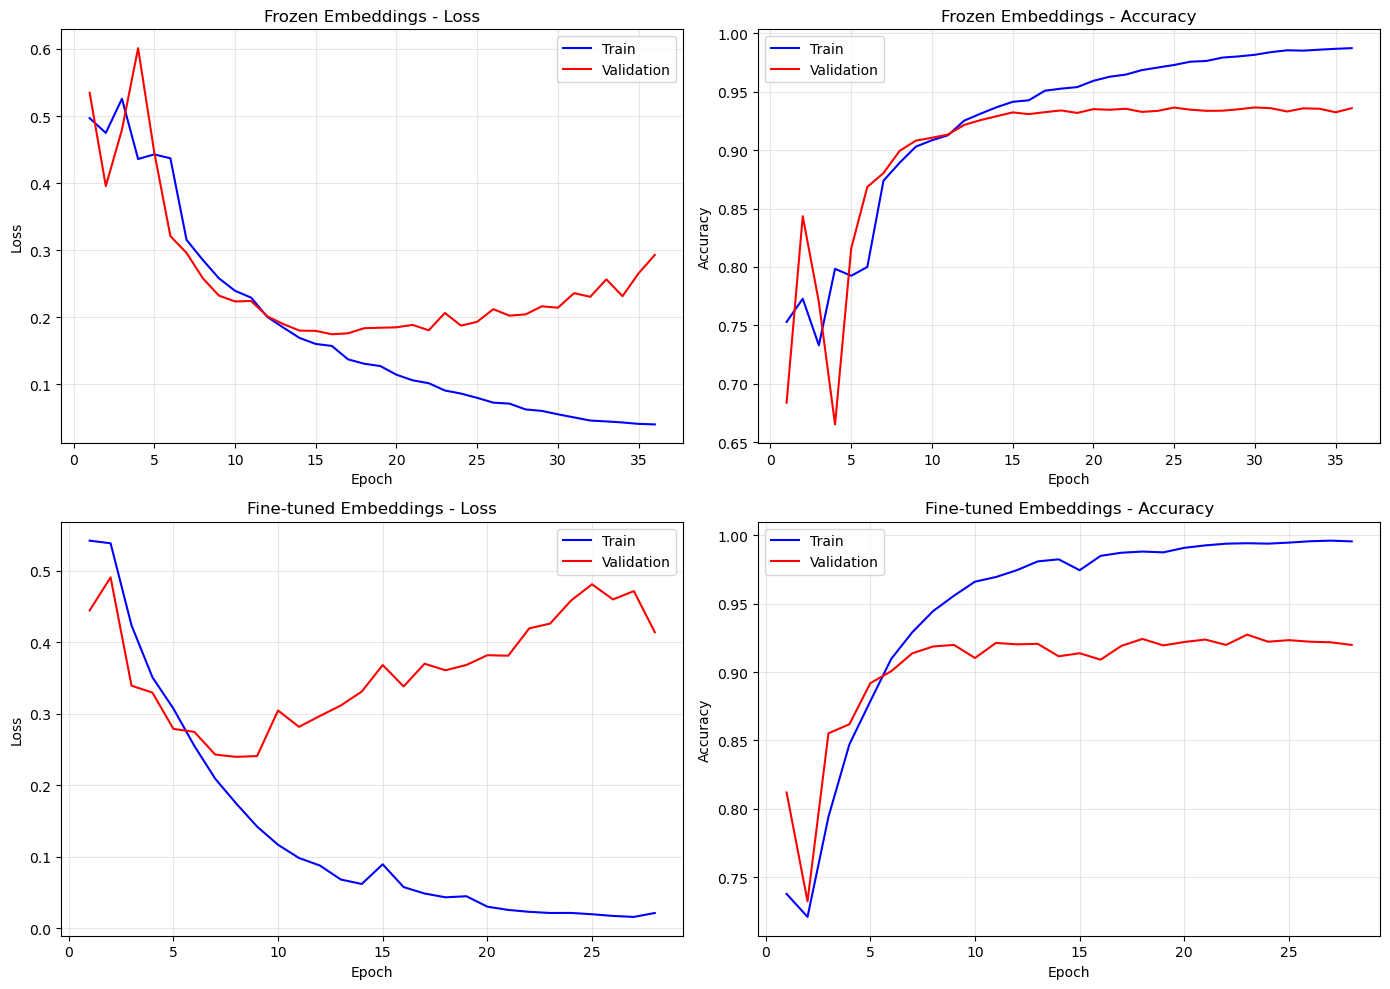


✓ Figure saved to results/figures/lstm_word2vec_comparison.png


In [15]:
# Plot training curves comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Frozen model plots
epochs_frozen = range(1, len(history_frozen['train_loss']) + 1)
axes[0, 0].plot(epochs_frozen, history_frozen['train_loss'], 'b-', label='Train')
axes[0, 0].plot(epochs_frozen, history_frozen['val_loss'], 'r-', label='Validation')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Frozen Embeddings - Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_frozen, history_frozen['train_acc'], 'b-', label='Train')
axes[0, 1].plot(epochs_frozen, history_frozen['val_acc'], 'r-', label='Validation')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Frozen Embeddings - Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Fine-tuned model plots
epochs_finetune = range(1, len(history_finetune['train_loss']) + 1)
axes[1, 0].plot(epochs_finetune, history_finetune['train_loss'], 'b-', label='Train')
axes[1, 0].plot(epochs_finetune, history_finetune['val_loss'], 'r-', label='Validation')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Fine-tuned Embeddings - Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_finetune, history_finetune['train_acc'], 'b-', label='Train')
axes[1, 1].plot(epochs_finetune, history_finetune['val_acc'], 'r-', label='Validation')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Fine-tuned Embeddings - Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'results' / 'figures' / 'lstm_word2vec_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure saved to results/figures/lstm_word2vec_comparison.png")


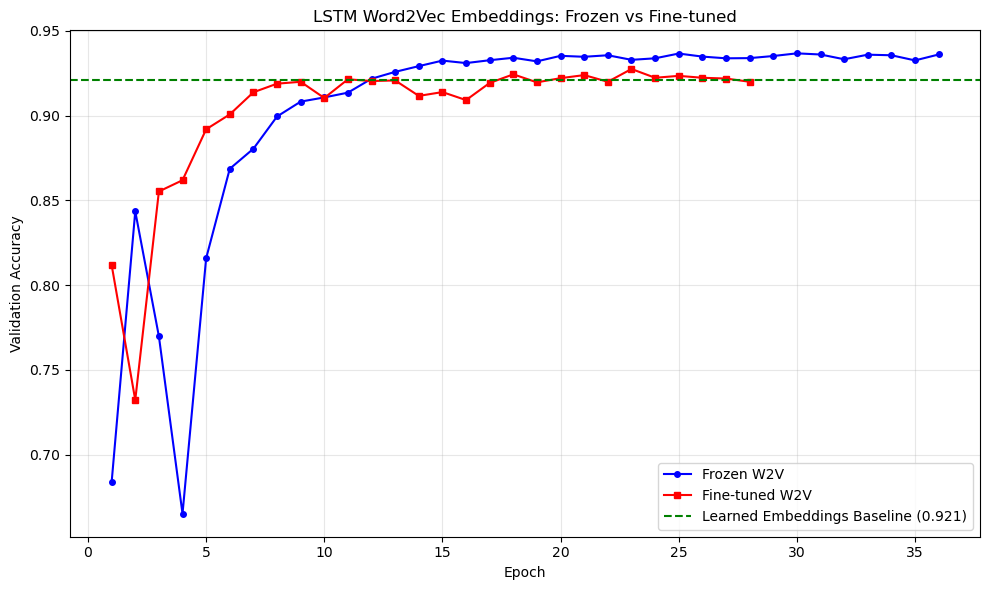

In [16]:
# Validation accuracy comparison overlay
plt.figure(figsize=(10, 6))

plt.plot(epochs_frozen, history_frozen['val_acc'], 'b-o', label='Frozen W2V', markersize=4)
plt.plot(epochs_finetune, history_finetune['val_acc'], 'r-s', label='Fine-tuned W2V', markersize=4)
plt.axhline(y=0.921, color='g', linestyle='--', label='Learned Embeddings Baseline (0.921)')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('LSTM Word2Vec Embeddings: Frozen vs Fine-tuned')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Detailed Classification Reports


In [17]:
print("="*60)
print("CLASSIFICATION REPORT: Frozen Word2Vec Embeddings")
print("="*60)
print(classification_report(
    labels_frozen, preds_frozen,
    target_names=['Real (0)', 'Fake (1)'],
    digits=4
))

print("\n" + "="*60)
print("CLASSIFICATION REPORT: Fine-tuned Word2Vec Embeddings")
print("="*60)
print(classification_report(
    labels_finetune, preds_finetune,
    target_names=['Real (0)', 'Fake (1)'],
    digits=4
))


CLASSIFICATION REPORT: Frozen Word2Vec Embeddings
              precision    recall  f1-score   support

    Real (0)     0.9475    0.9487    0.9481      5912
    Fake (1)     0.8979    0.8955    0.8967      2976

    accuracy                         0.9309      8888
   macro avg     0.9227    0.9221    0.9224      8888
weighted avg     0.9309    0.9309    0.9309      8888


CLASSIFICATION REPORT: Fine-tuned Word2Vec Embeddings
              precision    recall  f1-score   support

    Real (0)     0.9474    0.9295    0.9384      5912
    Fake (1)     0.8650    0.8975    0.8809      2976

    accuracy                         0.9188      8888
   macro avg     0.9062    0.9135    0.9096      8888
weighted avg     0.9198    0.9188    0.9191      8888



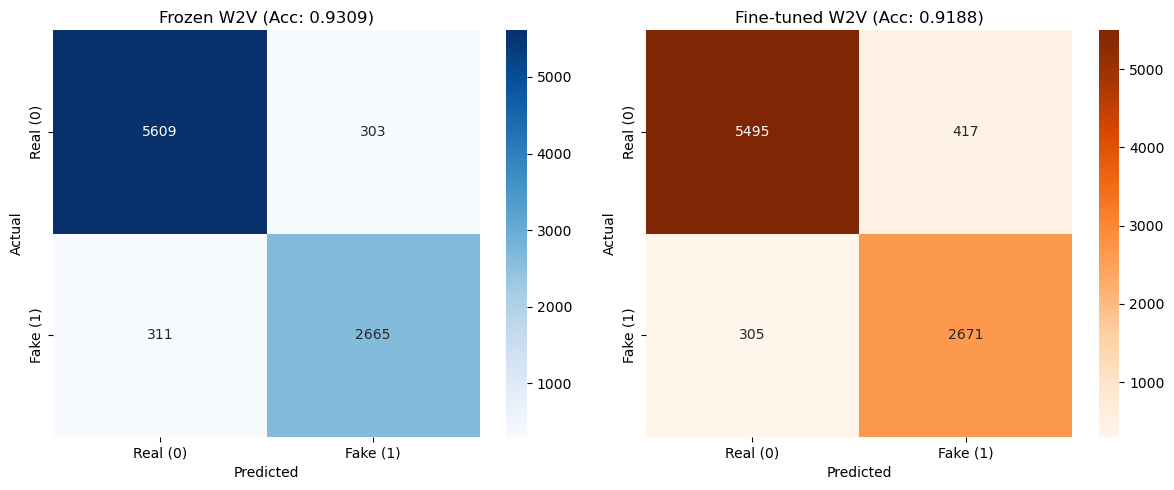

In [18]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Frozen
cm_frozen = confusion_matrix(labels_frozen, preds_frozen)
sns.heatmap(cm_frozen, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Frozen W2V (Acc: {acc_frozen:.4f})')

# Fine-tuned
cm_finetune = confusion_matrix(labels_finetune, preds_finetune)
sns.heatmap(cm_finetune, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Fine-tuned W2V (Acc: {acc_finetune:.4f})')

plt.tight_layout()
plt.show()


## 12. Save Best Model


In [19]:
# Save the better performing model
best_model = model_finetune if acc_finetune > acc_frozen else model_frozen
best_acc = max(acc_frozen, acc_finetune)
best_type = "fine-tuned" if acc_finetune > acc_frozen else "frozen"

model_save_path = project_root / "results" / "models" / "lstm_word2vec.pt"
torch.save({
    'model_state_dict': best_model.state_dict(),
    'embedding_type': best_type,
    'hyperparameters': {
        'vocab_size': len(vocab),
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': HIDDEN_DIM,
        'dropout': DROPOUT,
        'max_seq_len': MAX_SEQ_LEN
    },
    'test_accuracy': best_acc,
    'results': {
        'frozen_accuracy': acc_frozen,
        'frozen_f1': f1_frozen,
        'finetune_accuracy': acc_finetune,
        'finetune_f1': f1_finetune
    }
}, model_save_path)

print(f"✓ Best model ({best_type}) saved to: {model_save_path}")
print(f"  Accuracy: {best_acc:.4f}")


✓ Best model (frozen) saved to: /Users/alanye/Fake-News-Group-3/results/models/lstm_word2vec.pt
  Accuracy: 0.9309


## Summary

This experiment compared three LSTM embedding strategies:

| Model | Embeddings | Accuracy | F1 (macro) |
|-------|------------|----------|------------|
| LSTM + Learned (baseline) | Randomly initialized, trained | 0.9210 | 0.9100 |
| LSTM + Word2Vec (Frozen) | Pre-trained, fixed | See above | See above |
| LSTM + Word2Vec (Fine-tuned) | Pre-trained, updated | See above | See above |

**Key findings:**
- Pre-trained Word2Vec provides semantic initialization for embeddings
- Frozen embeddings reduce trainable parameters significantly
- Fine-tuning allows task-specific adaptation of embeddings
- Compare results with baseline to assess Word2Vec effectiveness for this task
